# Link-Level LTS Classification

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Project paths
DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')

CRS_BNG = 'EPSG:27700'

pd.set_option('display.max_columns', None)
print(f"Working directory: {os.getcwd()}")


Working directory: /Users/pippin/Library/CloudStorage/OneDrive2-UniversityCollegeLondon/Dissertation_CASA&TfWM/Code


## 1. Load Input Data

The link-level LTS classification adapts the Mekuria et al. (2012) framework by replacing its
North American thresholds with those from LTN 1/20, the statutory design standard for cycling
infrastructure in England and Northern Ireland. Although the breadth of CLoS's 25 subcriteria
prevents the tool from capturing population-level acceptability, the core subcriteria under
the Safety principle, addressing motor traffic speed (Criterion 10), volume (Criterion 11),
segregation provision and carriageway width (Criterion 12), are constructed on CROW-derived
logic that classifies conditions by the interaction between prevailing speed, traffic volume,
facility type, and available width (CROW, 2016), directly consistent with the LTS framework.
It is this subset that the present study selects for link-level LTS assignment.

LTN 1/20 further supplements these subcriteria with a speed-volume-facility matrix defining
which traffic conditions require protected, lane-based, or mixed-traffic provision for
"most people" to cycle. This population logic maps directly onto the LTS framework
conditions that LTN 1/20 deems suitable for most people, including children, correspond
to LTS 1; conditions that exclude some potential users correspond to LTS 2; conditions
suitable for few people correspond to LTS 3; and conditions triggering a critical safety
failure correspond to LTS 4 (Figure X).

| Facility type | LTS 1 | LTS 2 | LTS 3 | LTS 4 |
|---|---|---|---|---|
| Off-Road | All conditions | — | — | — |
| Shared Use | All conditions | — | — | — |
| Fully Kerbed Cycle Track | All conditions | — | — | — |
| Stepped cycle track | V85 ≤30 mph | V85 30–37 mph | ≥37 mph | — |
| Light segregation | V85 ≤30 mph | V85 30–37 mph | ≥37 mph | — |
| Mandatory cycle lane | Width ≥1.8m, V85 ≤20 mph, AADT ≤5,000 | Width ≥1.8m, V85 20–30 mph, AADT ≤5,000 | Width <1.8m; or V85 >30 mph; or AADT 5,000–10,000 | V85 ≥37 mph; or AADT ≥10,000 |
| Advisory cycle lane | Width ≥1.8m, V85 ≤20 mph, AADT ≤5,000 | Width ≥1.8m, V85 20–30 mph, AADT ≤5,000 | Width <1.8m; or V85 >30 mph; or AADT 5,000–10,000 | V85 ≥37 mph; or AADT ≥10,000 |
| Mixed traffic | V85 ≤20 mph, AADT ≤2,500 | V85 20–30 mph, AADT 2,500-5,000 | V85 30–37 mph; or AADT 5,000–10,000 | V85 ≥37 mph; or AADT ≥10,000; or nearside lane 3.2–3.9m and AADT ≥5,000|

**Notes:**

1. Where multiple criteria apply to a single segment, the overall LTS is determined by the worst-performing criterion (non-compensatory).
2. Thresholds are derived from the CLoS Safety subcriteria (Criteria 9–12, 15) in LTN 1/20 Appendix A, supplemented by the speed-volume-facility matrix in Figure 4.1, which the CLoS itself references as complementary guidance for determining appropriate separation levels.
3. Motor traffic speed is represented throughout by the estimated 85th percentile speed (V85), consistent with the measurement basis specified in LTN 1/20 Criteria 9 and 10. V85 is estimated from OS NGD average speed data (see Section 4.2).
4. Motor traffic volume is expressed as Annual Average Daily Traffic (AADT), used as a proxy for the passenger car unit (PCU) thresholds specified in LTN 1/20 Criterion 11. LTN 1/20 additionally specifies HGV composition thresholds (>5% for critical fail, 2–5% for score 0); these could not be applied due to the absence of network-wide vehicle composition data and are acknowledged as a limitation.
5. Rural exception - mixed traffic segments with V85 ≤30 mph and AADT ≤1,000 are classified as LTS 1, following LTN 1/20 Figure 4.1 Note 3.

### Speed

Prevailing speed is represented by the estimated 85th percentile speed (V85), consistent
with the measurement basis specified in CLoS. V85 is preferred over posted speed limits
because actual operating speeds frequently diverge from the limit depending on road geometry
and enforcement, offering a more reliable measure of cycling stress (Fitzpatrick and Program,
2003; European Commission, 2021; Department for Transport, 2025).
#### 85th Percentile Speed
The OS NGD Average and Indicative Speed dataset (Basemap, via PSGA) provides two relevant
fields

- **`indicativespeedlimit_mph`** the posted speed limit derived from road signage. This
  provides a legal upper bound but does not reflect actual driving speeds.
- **`averagespeed_*_kph`**: observed mean vehicle speeds from in-vehicle telematic systems,
  disaggregated by time period (8 weekday periods, 5 weekend periods) and direction of travel.

However, **individual vehicle speed distributions are not available** from this dataset.
The 85th percentile speed cannot be calculated directly, as it requires the full distribution
(or at minimum the standard deviation) of individual vehicle speeds at each link.

#### Estimation Approach: DMRB CA 185

To bridge this gap, this study applies the estimation method set out in the Design Manual for
Roads and Bridges (DMRB) CA 185 *Vehicle Speed Measurement* (National Highways, 2019).

DMRB CA 185 Equation 3.1.2a defines the 85th percentile speed as

$$p_{85} = m + s$$

where $m$ is the mean speed and $s$ is the standard deviation of measured vehicle speeds. This
formula is based on the established finding that speed distributions are "to all intents and
purposes normal (Gaussian)", and that the 85th percentile lies approximately one standard
deviation above the mean (Note 1 to Equation 3.1.2a).

Since the standard deviation is not available from the OS NGD average speed data, it is
estimated using the empirical relationship given in Note 3 to Equation 3.1.2a

$$s \approx \frac{m}{6}$$

Substituting into Equation 3.1.2a

$$p_{85} = m + \frac{m}{6} = \frac{7m}{6}$$

### Width

OS NGD provides carriageway width at the link level through average and minimum width
attributes. For cycle lanes, this study uses the separately recorded modal lane width rather
than the minimum, as it better captures typical conditions along a segment. For mixed traffic
on single carriageways, average road width is used to assess the critical nearside lane width
range of 3.2 to 3.9 m associated with elevated close-pass risk - on one-way roads, total width
serves directly as lane width; on two-way roads, lane width is approximated as half the total
width, with the override applied only where AADT exceeds 5,000, as lower volumes allow drivers
to overtake via the opposing lane. Segments triggering this override are classified as LTS 4.

### Traffic Volume

OS NGD does not include motor traffic volume attributes. To address this, major road volumes
were obtained directly from DfT annual average daily traffic (AADT) count point data, while
minor road volumes were estimated following the methodology of Morley and Gulliver (2016).
A Poisson GLM was constructed using road network characteristics extracted via pgRouting on
the England OSM network as predictors and DfT count point observations as the dependent
variable. Five-fold cross-validation (n = 3,695 count points) yields an R² of 0.604 ± 0.019
and Spearman's ρ of 0.803 ± 0.015, considered sufficient for the coarse-grained LTS
classification task. Predicted and observed AADT values were assigned to OS NGD links via
nearest-network spatial join. For the small number of links where no match was achieved,
volume was imputed using the median AADT of the corresponding road classification to ensure
network-wide coverage.

### Input Datasets

| File | Source | Content |
|---|---|---|
| `network_with_volume.gpkg` | `02_volume_projection` output | Cycleable network with facility type, AADT, road width, and network topology |
| `trn_rami_averageandindicativespeed.gpkg` | OS NGD (Basemap, via PSGA) | Indicative speed limits and observed average speeds for all road links |

In [2]:
# =============================================================================
# 1a. Load cycleable network with volume data
# =============================================================================

network = gpd.read_file(CLEANED_DIR / "network_with_volume.gpkg")
if network.crs != CRS_BNG:
    network = network.to_crs(CRS_BNG)

print(f"Network: {network.shape[0]:,} links, {network.shape[1]} columns")
print(f"\nFacility type distribution:")
print(network['facility_type'].value_counts())


Network: 480,228 links, 39 columns

Facility type distribution:
facility_type
Mixed Traffic               383335
Off-Road                     90046
Shared Use                    4668
Advisory Cycle Lane           1132
Fully Kerbed Cycle Track       681
Mandatory Cycle Lane           148
Light Segregation              146
Stepped Cycle Track             72
Name: count, dtype: int64


In [3]:
# =============================================================================
# 1b. Load and join OS NGD Speed Data
# =============================================================================

speed_data = gpd.read_file(
    DATA_DIR / "os_datasets_1/os_data/trn_rami_averageandindicativespeed.gpkg"
)

# Select speed limit + all average speed columns
speed_cols = ['osid', 'indicativespeedlimit_mph']
avg_speed_cols = [c for c in speed_data.columns
                  if 'averagespeed' in c and 'kph' in c]
speed_cols += avg_speed_cols

# Drop columns if they exist from a previous run
network = network.drop(columns=[c for c in speed_cols if c != 'osid' and c in network.columns],
                       errors='ignore')

# Join by osid
network = network.merge(speed_data[speed_cols], on='osid', how='left')

# -----------------------------------------------------------------------------
# Derive speed fields
# -----------------------------------------------------------------------------

# Average observed average speed (kph)
network['mean_avg_speed_kph'] = network[avg_speed_cols].mean(axis=1)

# Convert to mph
network['mean_avg_speed_mph'] = (
    network['mean_avg_speed_kph'] / 1.60934
)

# Estimate V85 in mph using CA185 proxy: V85 = mean * (7/6)
network['est_v85_mph'] = (
    network['mean_avg_speed_mph'] * (7 / 6)
)

# -----------------------------------------------------------------------------
# Convert width variables to numeric
# -----------------------------------------------------------------------------

network['roadwidth_average'] = pd.to_numeric(
    network['roadwidth_average'], errors='coerce'
)

network['roadwidth_minimum'] = pd.to_numeric(
    network['roadwidth_minimum'], errors='coerce'
)

network['cyclelaneinfo_minimumwidth_m'] = pd.to_numeric(
    network['cyclelaneinfo_minimumwidth_m'],
    errors='coerce'
)

network['cyclelaneinfo_modalwidth_m'] = pd.to_numeric(
    network['cyclelaneinfo_modalwidth_m'],
    errors='coerce'
)

# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------

print("Speed data coverage:")
print(
    f"  Speed limit: "
    f"{network['indicativespeedlimit_mph'].notna().sum():,} / {network.shape[0]:,}"
)
print(
    f"  Avg speed:   "
    f"{network['mean_avg_speed_mph'].notna().sum():,} / {network.shape[0]:,}"
)

print("\nSpeed limit distribution:")
print(
    network['indicativespeedlimit_mph']
      .value_counts()
      .sort_index()
)

print("\nEstimated V85 (mph) summary:")
print(
    network['est_v85_mph']
      .describe()
      .round(1)
)


Speed data coverage:
  Speed limit: 390,182 / 480,228
  Avg speed:   390,182 / 480,228

Speed limit distribution:
indicativespeedlimit_mph
5.0       2728
10.0      2289
15.0      1306
20.0     73340
30.0    298152
40.0      8371
50.0      1270
60.0      2608
70.0       118
Name: count, dtype: int64

Estimated V85 (mph) summary:
count    390182.0
mean         19.7
std           6.1
min           1.8
25%          15.9
50%          18.5
75%          22.4
max          90.4
Name: est_v85_mph, dtype: float64


## 2. LTS Classification by Facility Type

Classification proceeds from the most protected facility types (Off-Road, Shared Use,
Fully Kerbed Cycle Track), which receive a blanket LTS 1, through partially segregated
facilities (Stepped Cycle Track, Light Segregation), to on-carriageway facilities
(Mandatory and Advisory Cycle Lanes, Mixed Traffic), which require progressively more
input variables.

A directional complication arises for the 2,838 links where a bidirectional road carries
cycling infrastructure in only one direction (`cyclelaneinfo_direction == 'In Direction'`).
On these links the forward direction is classified according to the infrastructure present,
while the reverse direction — which lacks any cycling provision — is re-classified as
Mixed Traffic (Section 2.6). The two directions may therefore receive different LTS scores.

In [4]:
# --- Identify links WITH cycling infrastructure ---
has_cycle_infra = network['facility_type'].isin([
    'Shared Use', 'Advisory Cycle Lane', 'Fully Kerbed Cycle Track',
    'Mandatory Cycle Lane', 'Stepped Cycle Track', 'Light Segregation'
])

roads_with_infra = network[has_cycle_infra].copy()
print(f"\nRoad links with cycling infrastructure: {len(roads_with_infra):,}")
print(f"  out of {len(network):,} road links ({len(roads_with_infra)/len(network)*100:.1f}%)")
print()

# --- Cross-tab: directionality vs cyclelaneinfo_direction ---
print("=" * 60)
print("Cross-tab: Road Directionality × Cycle Lane Direction")
print("(Only links WITH cycling infrastructure)")
print("=" * 60)
ct = pd.crosstab(
    roads_with_infra['directionality'],
    roads_with_infra['cyclelaneinfo_direction'],
    margins=True,
    dropna=False
)
print(ct)
print()

# Also check sideoflink for context
print("=" * 60)
print("sideoflink distribution (links with cycling infra)")
print("=" * 60)
print(roads_with_infra['sideoflink'].value_counts(dropna=False))



Road links with cycling infrastructure: 6,847
  out of 480,228 road links (1.4%)

Cross-tab: Road Directionality × Cycle Lane Direction
(Only links WITH cycling infrastructure)
cyclelaneinfo_direction  Both Directions  In Direction   All
directionality                                              
Both Directions                     3077          1028  4105
In Direction                        1210           544  1754
In Opposite Direction                988             0   988
All                                 5275          1572  6847

sideoflink distribution (links with cycling infra)
sideoflink
Left      3762
Right     3042
Centre      43
Name: count, dtype: int64


### 2.1 Off-Road, Shared Use, and Fully Kerbed Cycle Track → LTS 1

Segments classified as Off-Road Cycle Track, Shared Use, or Fully Kerbed Cycle Track are
physically separated from general motor traffic and therefore eliminate direct interactions
between cyclists and moving vehicles. Such environments are generally considered suitable
for users of all ages and abilities, including children and less confident cyclists,
and represent the lowest level of traffic stress within the LTS framework.

Accordingly, all such segments are classified as **LTS 1** without further assessment of
traffic speed, motor vehicle flow, or carriageway characteristics.

In [5]:
# =============================================================================
# 2.1 Assign LTS 1 to off-carriageway facilities
# =============================================================================

OFF_CARRIAGEWAY_TYPES = {'Off-Road', 'Shared Use', 'Fully Kerbed Cycle Track'}

mask = network['facility_type'].isin(OFF_CARRIAGEWAY_TYPES)
network.loc[mask, 'lts'] = 1

print(f"LTS 1 assigned to {mask.sum():,} off-carriageway segments.")
print(network.loc[mask, 'facility_type'].value_counts())


LTS 1 assigned to 95,395 off-carriageway segments.
facility_type
Off-Road                    90046
Shared Use                   4668
Fully Kerbed Cycle Track      681
Name: count, dtype: int64


### 2.2 Stepped Cycle Track

Stepped cycle tracks provide vertical separation between cyclists and motor traffic. The
stress level is determined solely by prevailing speed (V85), as the physical step eliminates
direct interaction with traffic flow.

| V85 | LTS |
|---|---|
| ≤30 mph | 1 |
| 30–37 mph | 2 |
| ≥37 mph | 3 |

In [6]:
# =============================================================================
# 2.2 Assign LTS for Stepped Cycle Tracks (V85-based)
# =============================================================================

stepped = network['facility_type'] == 'Stepped Cycle Track'
v85 = network['est_v85_mph']

network.loc[stepped & (v85 <= 30), 'lts'] = 1
network.loc[stepped & (v85 > 30) & (v85 < 37), 'lts'] = 2
network.loc[stepped & (v85 >= 37), 'lts'] = 3

print(f"Stepped Cycle Track segments: {stepped.sum():,}")
print(network.loc[stepped, 'lts'].value_counts().sort_index())


Stepped Cycle Track segments: 72
lts
1.0    60
2.0    12
Name: count, dtype: int64


### 2.3 Light Segregation

Light segregation provides a degree of physical separation through features such as wands,
armadillos, or bolt-down separators. As with stepped cycle tracks, the stress level is
determined solely by prevailing speed (V85).

| V85 | LTS |
|---|---|
| ≤30 mph | 1 |
| 30–37 mph | 2 |
| ≥37 mph | 3 |

In [7]:
# =============================================================================
# 2.3 Assign LTS for Light Segregation (V85-based)
# =============================================================================

light = network['facility_type'] == 'Light Segregation'
v85 = network['est_v85_mph']

network.loc[light & (v85 <= 30), 'lts'] = 1
network.loc[light & (v85 > 30) & (v85 < 37), 'lts'] = 2
network.loc[light & (v85 >= 37), 'lts'] = 3

print(f"Light Segregation segments: {light.sum():,}")
print(network.loc[light, 'lts'].value_counts(dropna=False).sort_index())


Light Segregation segments: 146
lts
1.0    134
2.0      8
3.0      4
Name: count, dtype: int64


### 2.4 Mandatory and Advisory Cycle Lanes

Mandatory and advisory cycle lanes are classified using the same three-component
non-compensatory approach - cycle lane width, motor traffic volume (AADT), and prevailing
speed (V85). Each component is independently translated into an LTS score, and the overall
classification is determined by the worst-performing criterion.

Cycle lane width is represented using the modal width (`cyclelaneinfo_modalwidth_m`) rather
than the minimum. While minimum width reflects the most constrained sections of a facility,
modal width better represents the typical conditions experienced by cyclists along a route.

| Component | LTS 1 | LTS 2 | LTS 3 | LTS 4 |
|---|---|---|---|---|
| Width | ≥1.8 m | ≥1.8 m | <1.8 m | — |
| Speed (V85) | ≤20 mph | 20–30 mph | 30-37 mph | ≥37 mph |
| Volume (AADT) | ≤5,000 | ≤5,000 | 5,000–10,000 | ≥10,000 |

In [8]:
# =============================================================================
# 2.4 Assign LTS for Mandatory and Advisory Cycle Lanes
# =============================================================================

def assign_lts_cycle_lane(df, facility_name):
    """
    Assign LTS to cycle lanes using non-compensatory worst-indicator-wins logic.

    Components:
        - Width: modal cycle lane width (≥1.8 m → LTS 1, <1.8 m → LTS 3)
        - Speed: V85 (<20 → 1, 20–30 → 2, 30–37 → 3, >37 → 4)
        - Volume: AADT (≤5,000 → 1, 5,000–10,000 → 3, ≥10,000 → 4)

    Overall LTS = max(width, speed, volume).
    """
    mask = df['facility_type'] == facility_name
    v85 = df['est_v85_mph']
    flow = df['aadt']
    width = df['cyclelaneinfo_modalwidth_m']

    # Width component
    width_lts = pd.Series(np.nan, index=df.index)
    width_lts[width >= 1.8] = 1
    width_lts[width < 1.8] = 3

    # Speed component
    speed_lts = pd.Series(np.nan, index=df.index)
    speed_lts[v85 <= 20] = 1
    speed_lts[(v85 > 20) & (v85 <= 30)] = 2
    speed_lts[(v85 > 30) & (v85 < 37)] = 3
    speed_lts[v85 >= 37] = 4

    # Volume component
    flow_lts = pd.Series(np.nan, index=df.index)
    flow_lts[flow <= 5000] = 1
    flow_lts[(flow > 5000) & (flow < 10000)] = 3
    flow_lts[flow >= 10000] = 4

    # Overall LTS = max(width, speed, volume)
    df.loc[mask, 'lts'] = pd.concat(
        [width_lts[mask], speed_lts[mask], flow_lts[mask]],
        axis=1
    ).max(axis=1)

    print(f"{facility_name} LTS distribution:")
    print(df.loc[mask, 'lts'].value_counts(dropna=False).sort_index())
    return df


network = assign_lts_cycle_lane(network, 'Mandatory Cycle Lane')
print()
network = assign_lts_cycle_lane(network, 'Advisory Cycle Lane')


Mandatory Cycle Lane LTS distribution:
lts
1.0     2
2.0     4
3.0    95
4.0    47
Name: count, dtype: int64

Advisory Cycle Lane LTS distribution:
lts
1.0     25
2.0      2
3.0    594
4.0    511
Name: count, dtype: int64


### 2.5 Mixed Traffic

Mixed traffic segments are classified using a two-component non-compensatory approach based
on motor traffic volume (AADT) and prevailing speed (V85). Each component is independently
scored and the overall LTS is determined by the higher of the two.

| Component | LTS 1 | LTS 2 | LTS 3 | LTS 4 |
|---|---|---|---|---|
| Speed (V85) | ≤20 mph | 20–30 mph | 30–37 mph | ≥37 mph |
| Volume (AADT) | ≤2,500 | 2,500-5,000 | 5,000–10,000 | ≥10,000 |

Two additional modifiers are applied after the base classification

**Rural exception (LTN 1/20 Figure 4.1 Note 3):** Mixed traffic segments with V85 ≤30 mph
and AADT ≤1,000 are classified as LTS 1, recognising that achieving operating speeds of
20 mph may be impractical in rural settings and that shared routes with speeds of up to
30 mph may still be considered generally acceptable where motor traffic flows are very low.

**Critical-width override (LTN 1/20 Criterion 12):** On single carriageway roads, nearside
lane widths within the 3.2–3.9 m range are associated with elevated close-pass risk. For
one-way roads, total width serves directly as lane width. For two-way roads, lane width is
approximated as half the total width, with the override applied only where AADT exceeds
5,000, as lower volumes allow drivers to overtake via the opposing lane. Segments triggering
this override are classified as LTS 4.

In [9]:
# =============================================================================
# 2.5 Assign LTS for Mixed Traffic
# =============================================================================

def assign_lts_mixed_traffic(df):
    """
    Assign LTS to mixed traffic segments based on V85 speed and AADT,
    with rural exception and critical-width override.
    """
    mixed = df['facility_type'] == 'Mixed Traffic'
    v85 = df['est_v85_mph']
    flow = df['aadt']

    # -------------------------------------------------------------------------
    # Speed component
    # -------------------------------------------------------------------------
    speed_lts = pd.Series(np.nan, index=df.index)
    speed_lts[v85 <= 20] = 1
    speed_lts[(v85 > 20) & (v85 <= 30)] = 2
    speed_lts[(v85 > 30) & (v85 < 37)] = 3
    speed_lts[v85 >= 37] = 4

    # -------------------------------------------------------------------------
    # Traffic volume component
    # -------------------------------------------------------------------------
    flow_lts = pd.Series(np.nan, index=df.index)
    flow_lts[flow <= 2500] = 1
    flow_lts[(flow > 2500) & (flow <= 5000)] = 2
    flow_lts[(flow > 5000) & (flow < 10000)] = 3
    flow_lts[flow >= 10000] = 4

    # -------------------------------------------------------------------------
    # Base LTS = max(speed, flow)
    # -------------------------------------------------------------------------
    base_lts = pd.concat([speed_lts, flow_lts], axis=1).max(axis=1)
    df.loc[mixed, 'lts'] = base_lts[mixed]

    # -------------------------------------------------------------------------
    # Rural exception (LTN 1/20 Figure 4.1 Note 3)
    # V85 ≤30 mph AND AADT ≤1,000 → LTS 1
    # -------------------------------------------------------------------------
    rural_lts1 = (
        mixed
        & (v85 <= 30)
        & (flow <= 1000)
    )
    df.loc[rural_lts1, 'lts'] = 1

    # -------------------------------------------------------------------------
    # Critical-width override (LTN 1/20 Criterion 12)
    # Nearside lane 3.2–3.9 m → LTS 4
    # -------------------------------------------------------------------------
    is_sc = mixed & (df['description'] == 'Single Carriageway')

    # One-way: lane width = road width, no opposing lane to use
    critical_oneway = (
        is_sc
        & (df['directionality'] == 'In Direction')
        & df['roadwidth_average'].between(3.2, 3.9)
    )

    # Two-way: lane width ≈ road width / 2, need high flow to block overtaking
    critical_twoway = (
        is_sc
        & (df['directionality'] == 'Both Directions')
        & df['roadwidth_average'].between(6.4, 7.8)
        & (flow > 5000)
    )

    critical_width = critical_oneway | critical_twoway
    df.loc[critical_width, 'lts'] = 4
 
    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print("Mixed Traffic LTS distribution:")
    print(df.loc[mixed, 'lts'].value_counts(dropna=False).sort_index())
    print(f"\nRural exception applied: {rural_lts1.sum():,}")
    print(f"Critical-width override applied: {critical_width.sum():,}")
    print(f"  One-way:  {critical_oneway.sum():,}")
    print(f"  Two-way:  {critical_twoway.sum():,}")

    return df

network = assign_lts_mixed_traffic(network)


Mixed Traffic LTS distribution:
lts
1.0    229435
2.0     69513
3.0     41772
4.0     42615
Name: count, dtype: int64

Rural exception applied: 4,440
Critical-width override applied: 13,073
  One-way:  51
  Two-way:  13,022


## 3. LTS Classification Summary

The final link-level LTS is determined as the worst (highest) of the forward and reverse
direction scores. For the majority of links, both directions share the same classification;
only those with asymmetric cycling infrastructure (Section 2.6) may differ. Taking the
worst direction provides a conservative, undirected summary consistent with Furth et al.
(2016) and suitable for subsequent connectivity and accessibility analyses.

In [10]:
# =============================================================================
# 3. LTS Classification Summary
# =============================================================================

# Each directed edge now has its own LTS — no need for lts_reverse / lts_worst

print("=" * 60)
print("LTS distribution (per directed edge)")
print("=" * 60)
print(network['lts'].value_counts(dropna=False).sort_index())
print(f"\nUnclassified: {network['lts'].isna().sum():,}")

print("\nLTS by facility type:")
print(
    network.groupby('facility_type')['lts']
    .value_counts(dropna=False)
    .unstack(fill_value=0)
    .astype(int)
)

# Optional: worst-direction LTS per original link (for undirected comparison)
lts_worst = network.groupby('osid')['lts'].max().rename('lts_worst')
print(f"\n{'=' * 60}")
print("LTS worst-direction per original link (undirected view)")
print("=" * 60)
print(lts_worst.value_counts(dropna=False).sort_index())

# Directional asymmetry diagnostic
lts_by_dir = network.groupby('osid')['lts'].agg(['min', 'max'])
asym = (lts_by_dir['min'] != lts_by_dir['max']).sum()
print(f"\nLinks with different LTS by direction: {asym:,}")

LTS distribution (per directed edge)
lts
1.0    325051
2.0     69539
3.0     42465
4.0     43173
Name: count, dtype: int64

Unclassified: 0

LTS by facility type:
lts                          1.0    2.0    3.0    4.0
facility_type                                        
Advisory Cycle Lane           25      2    594    511
Fully Kerbed Cycle Track     681      0      0      0
Light Segregation            134      8      4      0
Mandatory Cycle Lane           2      4     95     47
Mixed Traffic             229435  69513  41772  42615
Off-Road                   90046      0      0      0
Shared Use                  4668      0      0      0
Stepped Cycle Track           60     12      0      0

LTS worst-direction per original link (undirected view)
lts_worst
1.0    167401
2.0     36436
3.0     25452
4.0     28285
Name: count, dtype: int64

Links with different LTS by direction: 341


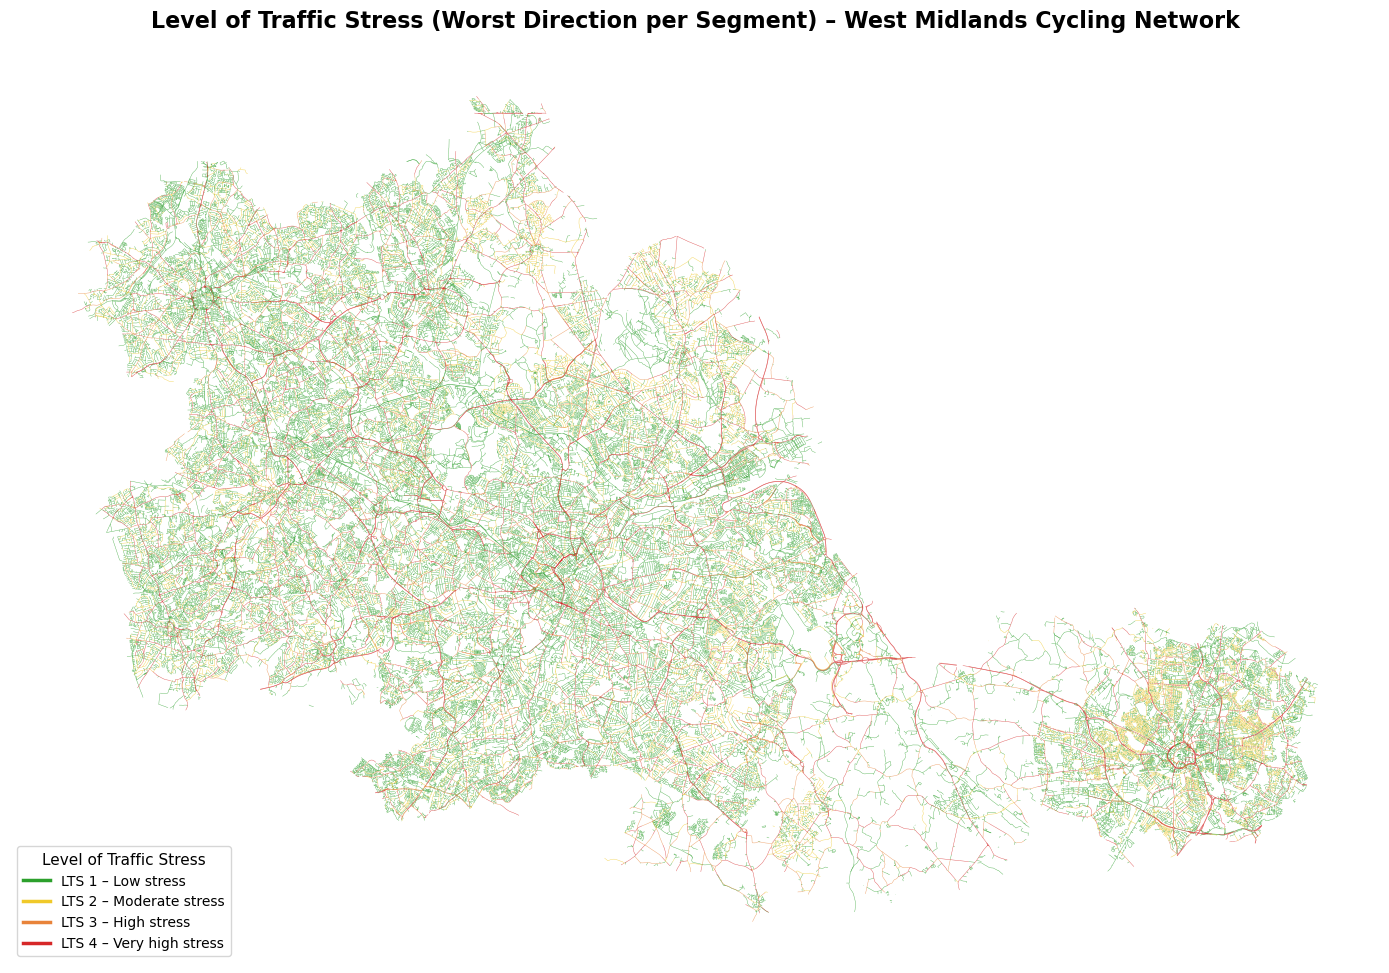

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# LTS colour scheme
lts_colors = {1: '#2ca02c', 2: '#f0c929', 3: '#e8833a', 4: '#d62728'}
lts_labels = {1: 'LTS 1 – Low stress', 2: 'LTS 2 – Moderate stress',
              3: 'LTS 3 – High stress', 4: 'LTS 4 – Very high stress'}

# Collapse directed edges → one row per original link, keeping worst LTS
lts_worst = network.groupby('osid').agg(
    lts_worst=('lts', 'max'),
    geometry=('geometry', 'first')
)
lts_worst = gpd.GeoDataFrame(lts_worst, geometry='geometry', crs=network.crs)

fig, ax = plt.subplots(figsize=(14, 16))

for lts in [1, 2, 3, 4]:
    subset = lts_worst[lts_worst['lts_worst'] == lts]
    subset.plot(ax=ax, color=lts_colors[lts], linewidth=0.3, alpha=0.8)

legend_elements = [
    Line2D([0], [0], color=lts_colors[i], linewidth=2.5, label=lts_labels[i])
    for i in [1, 2, 3, 4]
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10,
          frameon=True, facecolor='white', edgecolor='#cccccc',
          title='Level of Traffic Stress', title_fontsize=11)

ax.set_axis_off()
ax.set_title('Level of Traffic Stress (Worst Direction per Segment) – West Midlands Cycling Network',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 4. Export

The classified network is exported as a GeoPackage for use in subsequent notebooks.
Intermediate average speed columns are dropped to reduce file size; only the derived
`est_v85_mph` field is retained. The output contains the original link geometry and
attributes alongside `lts` (forward direction), `lts_reverse`, and `lts_worst`.

In [13]:
# =============================================================================
# 4. Export
# =============================================================================

# Drop intermediate average speed columns to reduce file size
drop_cols = [c for c in network.columns if 'averagespeed' in c]
network_export = network.drop(columns=drop_cols, errors='ignore')

output_path = OUTPUT_DIR / "network_lts_classified.gpkg"
network_export.to_file(output_path, driver='GPKG')

print(f"Exported to: {output_path}")
print(f"  Links: {network_export.shape[0]:,}")
print(f"  Columns: {network_export.shape[1]}")


Exported to: ../Data/Cleaned/network_lts_classified.gpkg
  Links: 480,228
  Columns: 44
